**<h1>1. Définition</h1>**

**<h2>🔁 Réseaux de Neurones Récurrents (RNNs)</h2>**

🧠 Les **réseaux de neurones récurrents (RNNs)** sont conçus pour traiter des **données séquentielles** 🧵 (c’est-à-dire quand **l’ordre des éléments compte** ⏱️).
<br><br>
**<h2>🌍 Applications en Traitement du Langage Naturel (NLP)**

📌 Les RNNs ont trouvé des applications remarquables en **traitement automatique du langage** (NLP) telles que :  
- 🗣️ **Analyse de sentiments**  
- 🏷️ **Reconnaissance d’entités nommées**  
- 🌐 **Traduction automatique**
<br><br>
**<h2>🎶 Autres domaines d’application**

En dehors du NLP, les RNNs peuvent aussi être utilisés pour :  
- 📈 **Prédiction de séries temporelles**  
- 🎧 **Transcription audio**  
- 🎲 **Génération de séquences**


In [ ]:
# Illustration d'un réseau Seq2Seq avec un RNN
url ="https://miro.medium.com/v2/resize:fit:1200/1*gPHO3MURK-LsuYc08dJexQ.gif"
from IPython.display import Image
Image(url=url)

**<h1>2. Exemple d'application</h1>**

**<h2>📌 Example of application</h2>**

* Consider the sentence :  
  * **She works at Apple since she graduated.**  

🍏 Ici, le mot **Apple** fait référence à l’**entreprise** et non au fruit.  

🔎 En linguistique / NLP, ce type de mots sont appelés **Entités Nommées** (*Named Entities*).  

👉 Si l’on veut reconnaître automatiquement les **entités nommées**, on remarque que ce sont surtout les mots **works** et **at** qui indiquent que **Apple** est une entité nommée.  



**<h2>🧮 Représentation des mots en Machine Learning</h2>**  

Quand une phrase est donnée en entrée sous forme de **séquence de mots**, chaque mot est représenté par un **vecteur**.  
La phrase ci-dessus peut être encodée en **one-hot** comme suit :  

\begin{equation}
\begin{bmatrix}
\mbox{she:} & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
\mbox{works:} & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
\mbox{at:} & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
\mbox{apple:} & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
\mbox{since:} & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
\mbox{she:} & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
\mbox{graduated:} & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
\end{equation}



**<h2>🤖 Modèle pour prédire les entités nommées</h2>**  

- La phrase en entrée est notée $x$, avec $T_x$ mots.  
- Les mots $\{x_t, \; t = 1, \ldots, T_x\}$ sont traités **séquentiellement**.  
- À chaque $x_t$, le modèle donne une sortie $y_t$:  
  - $y_t = 1$ si le mot est une **entité nommée** 🏷️  
  - $y_t = 0$ sinon  



**<h2>🧠 Architecture RNN simplifiée</h2>**  

- Composée d’unités de type **MLP**  
- Traite un mot $x_t$ à la fois  
- Utilise l’état caché précédent $h_{t-1}$ comme **mémoire** 🔁  


**<h1>3. Architecture</h1>**

In [ ]:
url ="https://miro.medium.com/v2/resize:fit:960/1*TqcA9EIUF-DGGTBhIx_qbQ.gif"
from IPython.display import Image
Image(url=url)

**<h2>🧠 Architecture d’un RNN</h2>**

* Soit $x \in [T_x \times d]$ la séquence en entrée  
* Soit $y \in \mathbb{R}^k$ la sortie cible  

Le RNN est défini comme une fonction qui traite la séquence $x$ :

$$
\mbox{RNN}(x) =
\left\{
\begin{array}{ll}
h_t = a\left(\mathbf{W}_{hx} x_{t} +  \mathbf{W}_{hh} h_{t-1} + b_{h} \right), \\\\
y_t = a\left( \mathbf{W}_{y} h_{t} + b_{y} \right). \\\\
\end{array}
\right.
$$


**<h2>📌 Explications :</h2>**  
- $x_t$ → mot (ou vecteur) en entrée à l’instant $t$ 🧩  
- $h_t$ → état caché à l’instant $t$ (la **mémoire** 🔁 du modèle)  
- $y_t$ → sortie du modèle à l’instant $t$  
- $W_{hx}, W_{hh}, W_y$ → matrices de poids 🎛️  
- $b_h, b_y$ → biais ⚖️  



**<h2>⚡ Fonction d’activation $a(.)$ :</h2>**  
- Dans les **couches cachées** :  
  - $\tanh$ ou ReLU  
- Dans les **couches de sortie** :  
  - linéaire (régression 🔢)  
  - softmax (classification 🏷️)  

---

**<h2>🔗 Simplification avec concaténation</h2>**

👉 Les matrices $\mathbf{W}_{hx}$ et $\mathbf{W}_{hh}$ peuvent être **concaténées**, puis appliquées directement sur la concaténation de $x_t$ et $h_{t-1}$ :

$$
\mbox{RNN}(x) =
\left\{
\begin{array}{ll}
h_t = a\left(\mathbf{W}_{h}[x_{t}, h_{t-1}] + b_{h} \right), \\\\
\\\\
y_t = a\left( \mathbf{W}_{y} h_{t} + b_{y} \right). \\\\
\end{array}
\right.
$$


**<h2>📌 Explications :</h2>**  
- On **concatène** l’entrée $x_t$ et l’état caché précédent $h_{t-1}$ 👉 $[x_t, h_{t-1}]$  
- On utilise une seule matrice de poids $\mathbf{W}_h$ au lieu de deux séparées $(\mathbf{W}_{hx}, \mathbf{W}_{hh})$  
- Cela simplifie la notation et le calcul ✨  
- L’état caché $h_t$ garde toujours la **mémoire** 🔁 de la séquence  
- La sortie $y_t$ est produite de la même manière qu’avant  

---


**<h2>🎯 Fonctions de perte et entraînement des RNNs</h2>**

* Les fonctions de perte $J$ comme **MSE** (erreur quadratique moyenne) ou **Entropie Croisée** restent applicables dans les RNNs ⚖️  

* Dans les RNNs, les fonctions de perte $J$ et l’algorithme de rétropropagation sont calculés sur la **version déroulée** (*unrolled*) du réseau 🔁  

📥 Soient $x, y$ des séquences d’entrée et de sortie de taille $T$, et $\mbox{RNN}(x)$ un réseau récurrent avec paramètres $\boldsymbol{\theta}$ :  

$$
J(\boldsymbol{\theta},x,y) = \sum_{t = 1}^{T_x} J_t(\boldsymbol{\theta},x_t,y_t).
$$



**<h2>⚡ Backpropagation Through Time (BPTT)</h2>**  

- Le gradient $\nabla_{\boldsymbol{\theta}} J_t$ est calculé à **chaque pas de temps $t$** ⏱️  
- Puis les gradients sont **moyennés** pour mettre à jour les paramètres $\boldsymbol{\theta}$ 🔧  



**<h2>📌 Idée clé :</h2>**  
Un RNN s’entraîne comme un réseau classique, mais en tenant compte de la **dépendance temporelle** : on déroule le réseau dans le temps, on calcule les pertes et gradients à chaque étape, puis on fait la mise à jour globale.


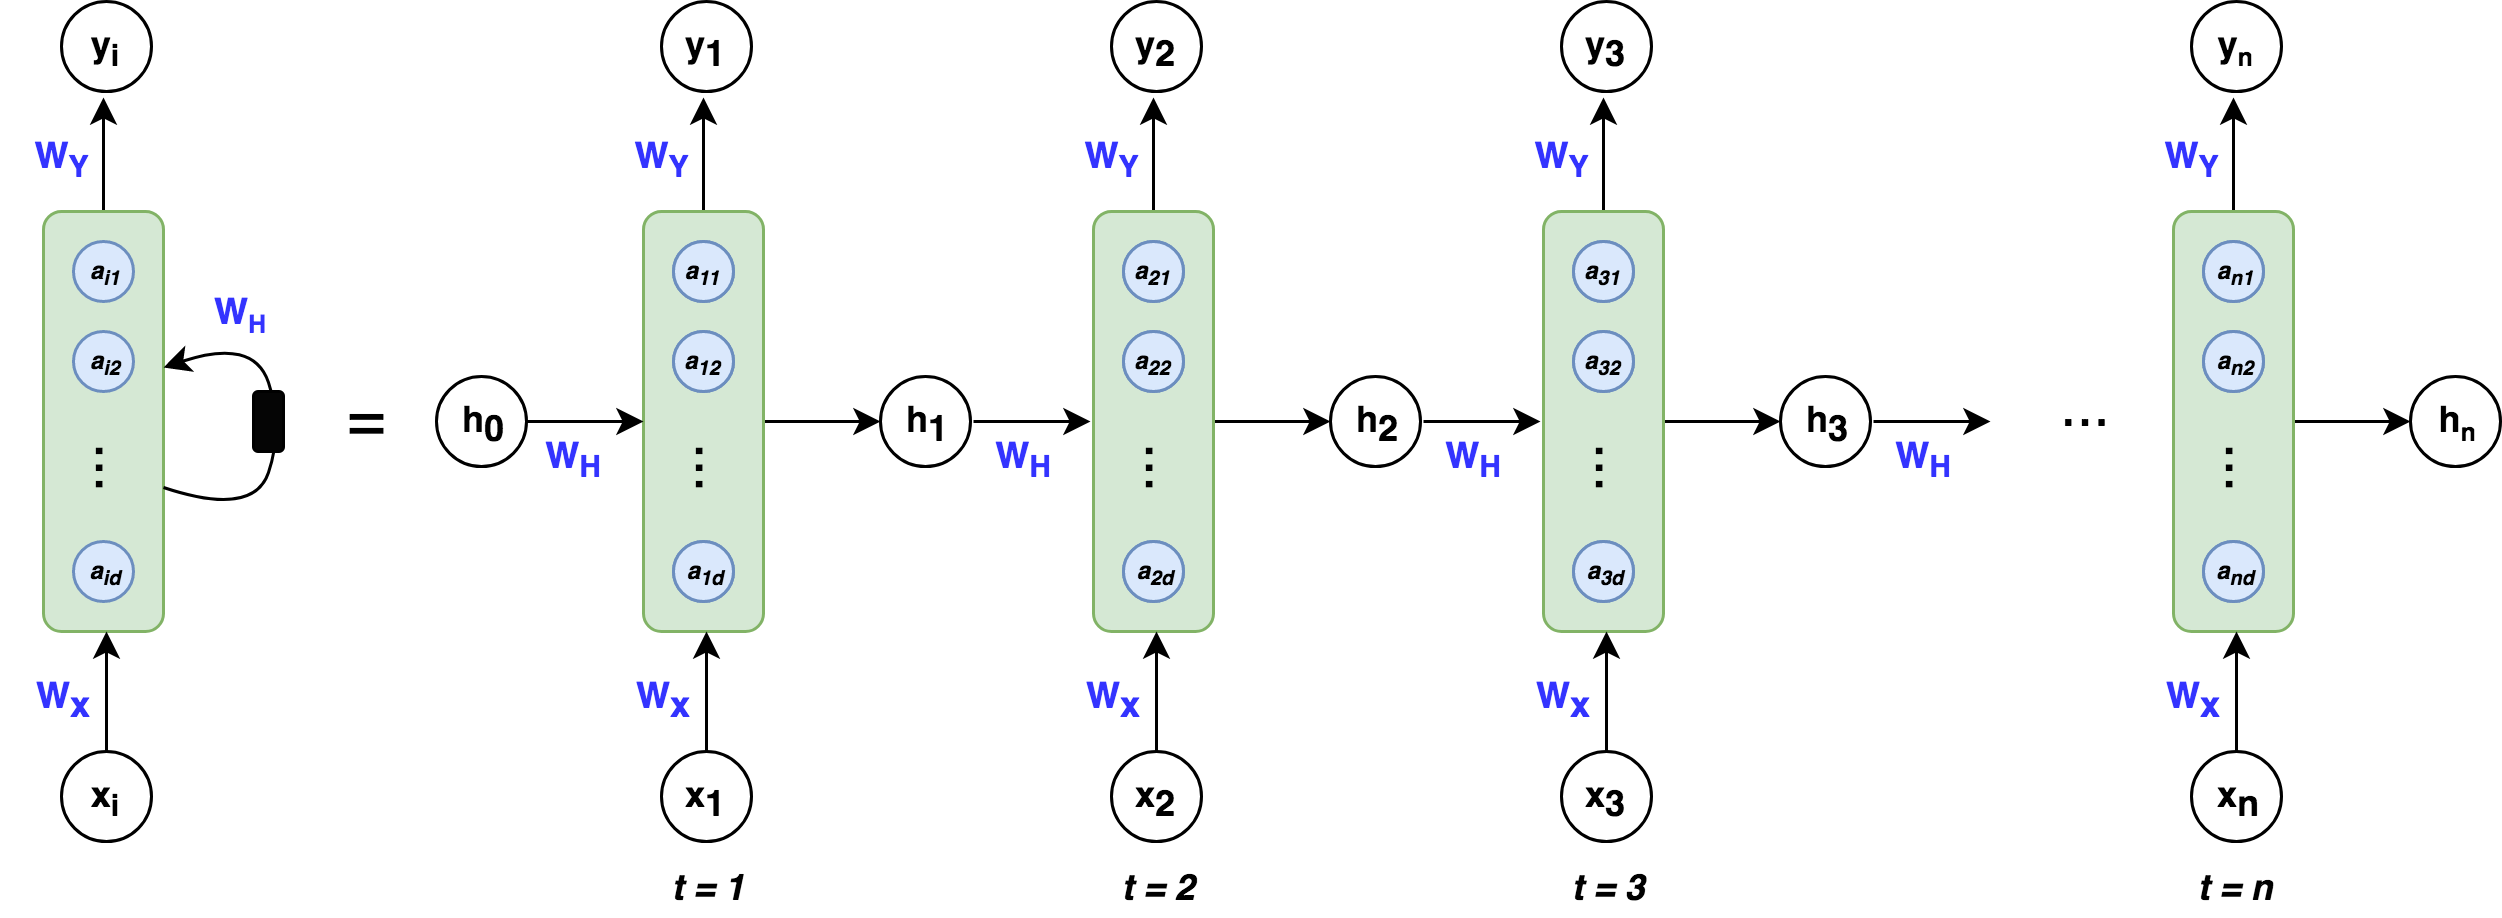

**<h1> 4. Types de RNN</h1>**

🔀 **Types de RNN**

* Les architectures de RNN varient selon la **tâche** pour laquelle elles sont conçues 🎯  

* Deux critères principaux influencent l’architecture :  

1️⃣ **Liés à la tâche (Task related)**  
- Longueur des séquences d’entrée et de sortie $(T_x, T_y)$  
👉 Exemple :  
- Une phrase traduite en une autre → $T_x \neq T_y$  
- Une analyse de sentiment (entrée = phrase, sortie = label) → $T_y = 1$  

2️⃣ **Liés au modèle (Model related)**  
- **Profondeur** du modèle (nombre de couches empilées 🏗️)  
- **Direction** de l’information :  
  - unidirectionnelle ⏩ (du passé vers le futur)  
  - bidirectionnelle 🔄 (prend aussi en compte le futur par rapport au mot courant)  


📌 **Idée clé :**  
Selon la tâche et la complexité désirée, on peut choisir un RNN plus ou moins profond, et unidirectionnel ou bidirectionnel.


**<h2> 1️⃣ Liés à la tâche (Task related)</h2>**

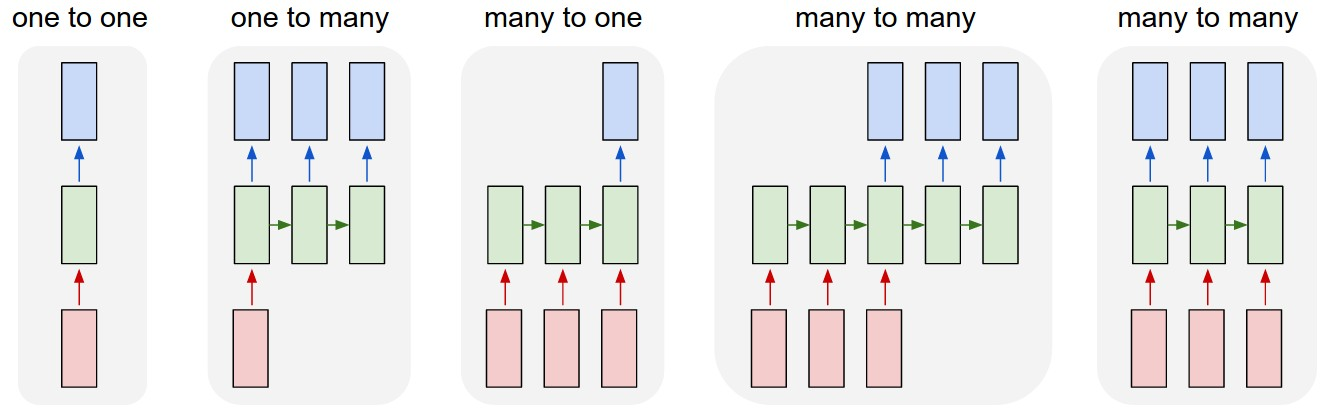


📚 **Many To Many** (cas 1)

* Situation : $T_x = T_y$  
* Exemple d’application : **Identification des fonctions grammaticales** 🏷️  


❤️ **Many To One**

* Situation : $T_x$ variable et $T_y = 1$  
* Exemple d’application : **Analyse de sentiments** 🙂😡  



🌐 **Many To Many** (cas 2)

* Situation : $T_x \neq T_y$  
* Exemple d’application : **Traduction automatique** 🌍🗣️  


✍️ **One To Many**

* Situation : $T_x = 1$, $T_y > 1$  
* Exemple d’application : **Génération de texte** 📝✨  


**<h2>2️⃣ Liés au modèle (Model related)</h2>**

**🔄 A. Bidirectional RNNs**

* Les **RNN bidirectionnels** sont utiles quand **toute la séquence d’entrée est disponible** 📜  
* La sortie $y_t$ tient compte **à la fois du passé et du futur** par rapport au mot courant ⏪⏩  


🧮 Formulation :  

$$
\mbox{Bi-RNN}(x) =
\left\{
\begin{array}{ll}
h_t^p = a\left(\mathbf{W}_{h^p}[x_{t}, h_{t-1}^p] + b_{h^p} \right), \\\\
\\\\
h_t^f = a\left(\mathbf{W}_{h^f}[x_{t}, h_{t+1}^f] + b_{h^f} \right), \\\\
\\\\
y_t = a\left( \mathbf{W}_{y} \left[h_{t}^p, h_{t}^f \right] + b_{y} \right). \\\\
\end{array}
\right.
$$



**📌 Explications :**  
- $h_t^p$ : état caché calculé en **parcourant la séquence vers l’avant** ⏩  
- $h_t^f$ : état caché calculé en **parcourant la séquence vers l’arrière** ⏪  
- La sortie $y_t$ combine les deux représentations → elle contient **contexte passé + futur** 🔀  

💡 Exemple d’application : **Reconnaissance d’entités nommées** (le sens d’un mot dépend souvent de ce qui vient avant *et* après).


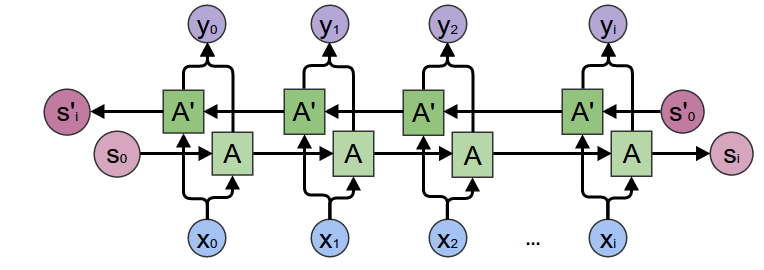

**🏗️ B. Deep RNN**

* Les **Deep RNNs** empilent plusieurs couches cachées 🔝  
* Chaque couche cachée à l’instant $t-1$ ne nourrit que **la couche du même rang à l’instant $t$** ⏱️  


**💡 Remarque :**  
- Les Deep RNN peuvent aussi être **Bidirectionnels** 🔄  
- Cela permet d’avoir **plus de capacité d’apprentissage** et de **modéliser des séquences complexes**.


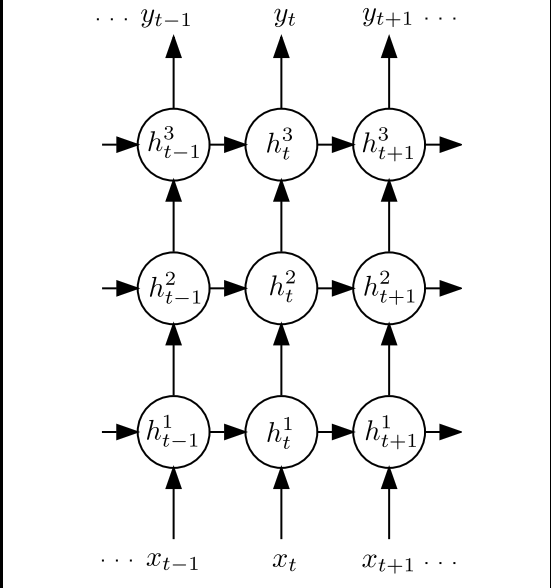

**<h1>5. RNN avec Keras</h1>**

* Dans Keras, toutes les séquences d’entrée doivent être **formatées** comme suit :  

$$
\text{# examples} \times  \text{# timestamps} \times \text{# features}
$$


📌 Exemple :  

- 100 phrases (examples)  
- Chaque phrase de 10 mots (timestamps)  
- Chaque mot représenté par un vecteur de 50 dimensions (features)  
<br>

🔁  La couche **[SimpleRNN](https://keras.io/api/layers/recurrent_layers/simple_rnn/)** implémente **la couche cachée récurrente** $h_t$: $y_t = h_t$
<br>

🏷️ Pour obtenir une architecture **Many to One** :  
- Connecter la couche **SimpleRNN** à une **Dense Layer** (couche entièrement connectée)  
- La Dense Layer produit la sortie finale $y$ (ex : label pour analyse de sentiment)  
<br>

💡 Astuce :  
- `return_sequences=False` dans SimpleRNN → Many-to-One  
- `return_sequences=True` → Many-to-Many


In [ ]:
#🛠️ Example: Build a Simple RNN in Keras

import tensorflow as tf

# 🔁 Simple RNN layer
rnn_layer = tf.keras.layers.SimpleRNN(
    units=10,               # Nombre de neurones dans la couche cachée 🧠

    activation="tanh",      # Fonction d'activation (par défaut "tanh") ⚡

    return_sequences=False, # True: retourne h_t pour chaque timestamp t=1,...,Tx
                            # Utile pour construire des Deep RNNs 🏗️

    return_state=False,     # True: retourne le dernier état caché h_Tx 📦

    stateful=False          # True: mémorise l'état caché pour la prochaine prédiction 🔄
)


In [ ]:
## 📝 Example: RNN for Sentiment Analysis
import tensorflow as tf

# 📥 Input layer: 10 timestamps, 64 features each
input_layer = tf.keras.layers.Input(shape=(10, 64))

# 🔁 Simple RNN layer with 10 hidden units
x = tf.keras.layers.SimpleRNN(10, return_sequences=False)(input_layer)

# 🏷️ Dense layer for output (Many-to-One architecture)
x = tf.keras.layers.Dense(1, activation="sigmoid")(x)

# 🔧 Build the model
model = tf.keras.Model(inputs=input_layer, outputs=x)

# 📊 Summary of the model
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 761 (2.97 KB)

 Trainable params: 761 (2.97 KB)

 Non-trainable params: 0 (0.00 B)

**📐 Calcul du nombre de paramètres dans une couche SimpleRNN**

Le nombre de paramètres peut être calculé avec la formule :  

$$
\text{Params} = (x + h) \times h + h
$$

où :  
- $x$ = nombre de **features** (dimension du vecteur d’entrée par timestamp) 🧩  
- $h$ = nombre de **neurones dans la couche cachée** 🧠  


**📌 Explication :**  
1. $(x \times h)$ → poids entre l’entrée $x_t$ et la couche cachée $h_t$ 🔗  
2. $(h \times h)$ → poids entre l’état caché précédent $h_{t-1}$ et le nouvel état caché $h_t$ 🔁  
3. $+ h$ → biais pour chaque neurone de la couche cachée ⚖️  

💡 Exemple :  
- Si $x=64$ (features) et $h=10$ (units) :  
$$
(64 + 10) * 10 + 10 = 750 \text{ paramètres}
$$



* La classe **[Bidirectional](https://keras.io/api/layers/recurrent_layers/bidirectional/)** est un wrapper qui permet de gérer les états cachés **passés et futurs**.

* Pour implémenter une architecture **Many-to-Many** de même longueur :

  * régler `return_sequences = True` dans la couche récurrente ;
  * envelopper la couche de sortie avec **[TimeDistributed](https://keras.io/api/layers/recurrent_layers/time_distributed/)**.

* À noter : **TimeDistributed** peut aussi être utilisé sur la couche d’entrée. Cela se produit lorsque $x_t$ doit passer par un CNN avant d’être injecté dans la couche récurrente.

* 🔹 **Explication TimeDistributed** :

  * Le wrapper **applique la même couche (avec les mêmes paramètres)** à chaque élément de la séquence séparément.
  * Exemple :

    * Sans TimeDistributed : une `Dense(10)` appliquée sur toute la séquence → la couche traite toute la séquence comme un seul vecteur.
    * Avec TimeDistributed : `TimeDistributed(Dense(10))` applique la même Dense à **chaque timestamp séparément**, en conservant les mêmes poids pour chaque élément de la séquence.


In [ ]:
## 🔄 Example: Bidirectional RNN

import tensorflow as tf

# 📥 Input layer: sequences of arbitrary length, each x_t has 3 features
input_layer = tf.keras.layers.Input((None, 3))  # (None, 3)

# 🔁 Bidirectional SimpleRNN with 64 units
h = tf.keras.layers.Bidirectional(
        tf.keras.layers.SimpleRNN(64, activation='tanh')
    )(input_layer)

# 🏷️ Dense output layer
output = tf.keras.layers.Dense(1)(h)

# 🔧 Build the model
model = tf.keras.Model(inputs=input_layer, outputs=output)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## 🔄 Example: Bidirectional RNN + TimeDistributed

import tensorflow as tf

# 📥 Input layer: sequences of arbitrary length, each x_t has 3 features
input_layer = tf.keras.layers.Input((None, 3))  # (None, 3)

# 🔁 Bidirectional SimpleRNN with 64 units, return sequences=True for Many-to-Many
h = tf.keras.layers.Bidirectional(
        tf.keras.layers.SimpleRNN(64, activation='tanh', return_sequences=True)
    )(input_layer)

# 🏷️ Apply a Dense layer to each timestamp separately using TimeDistributed
output = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))(h)

# 🔧 Build the model
model = tf.keras.Model(inputs=input_layer, outputs=output)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, None, 128)      │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, None, 1)        │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

**<h1>6. EXEMPLE D’APPLICATION D’UN RNN EN ANALYSE DE SENTIMENTS</h1>**

In [5]:
# ========================================
# EXEMPLE D'APPLICATION D'UN RNN EN ANALYSE DE SENTIMENTS
# ========================================

# 📦 Import des packages
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
import numpy as np
import string

In [17]:
# Version de tf sur colab
print(tf.__version__)

2.20.0


In [6]:
# ========================================
# 1️⃣ Chargement du dataset IMDB
# ========================================

num_words = 10000  # Limite le vocabulaire aux 10 000 mots les plus fréquents
maxlen = 100       # Longueur maximale des séquences

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

# Inspection des deux premières séquences (listes d'entiers)
print("Longueur de la première séquence d'entraînement :", len(x_train[0]))
print("Longueur de la deuxième séquence d'entraînement :", len(x_train[1]))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Longueur de la première séquence d'entraînement : 218
Longueur de la deuxième séquence d'entraînement : 189


In [15]:
# Voir le vocabualire
imdb.get_word_index()

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [25]:
index_word = {v: k for k, v in imdb.get_word_index().items()}

In [21]:
y_train

array([1, 0, 0, ..., 0, 1, 0])

In [26]:
text = ""
for word_id in x_train[0]:
  text+=index_word[word_id]
  text+=" "
print(text)

critics they is you that isn't one will very to as itself with other and in of seen over landed for anyone of and br show's to whether from than out themselves history he name half some br of and odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but when from one bit then have two of script their with her nobody most that with wasn't to with armed acting watch an for with heartfelt film want an 


In [27]:
text = ""
for word_id in x_train[1]:
  text+=index_word[word_id]
  text+=" "
print(text)

makes this stretch and of solid it thought begins br senator and budget worthwhile though ok and awaiting for ever better were and diverse for budget look kicked any to of making it out and follows for effects show to show cast this family us scenes more it severe making senator to and finds tv tend to of emerged these thing wants but and an beckinsale cult as it is video do you david see scenery it in few those are of ship for with of wild to one is very work dark they don't do dvd with those them 


In [7]:
# ========================================
# 2️⃣ Padding des séquences pour uniformiser leur longueur
# ========================================

x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Forme de x_train après padding :", x_train.shape)
print("Forme de x_test après padding :", x_test.shape)


Forme de x_train après padding : (25000, 100)
Forme de x_test après padding : (25000, 100)


In [8]:
# ========================================
# 3️⃣ Nombre de classes
# ========================================

print("Labels uniques dans y_train :", np.unique(y_train))


Labels uniques dans y_train : [0 1]


In [9]:
# ========================================
# 4️⃣ Construction du modèle RNN
# ========================================

# Couche d'entrée
inputs = Input(shape=(maxlen,))

# Couche d'embedding (nombre de paramètres 10000*128): Chaque mot du vocabulaire est représenté par 128 paramètres.
x = Embedding(input_dim=num_words, output_dim=128)(inputs)
print("Forme après Embedding :", x.shape)

# Première couche SimpleRNN (Many-to-Many)
x = SimpleRNN(64, return_sequences=True)(x)
print("Forme après première SimpleRNN (return_sequences=True) :", x.shape)

# Deuxième couche SimpleRNN (Many-to-One)
x = SimpleRNN(128)(x)
print("Forme après deuxième SimpleRNN (return_sequences=False) :", x.shape)

# Couche de sortie
outputs = Dense(1, activation='sigmoid')(x)
print("Forme de la sortie :", outputs.shape)

# Création du modèle
model = Model(inputs=inputs, outputs=outputs)

# Résumé du modèle
model.summary()


Forme après Embedding : (None, 100, 128)
Forme après première SimpleRNN (return_sequences=True) : (None, 100, 64)
Forme après deuxième SimpleRNN (return_sequences=False) : (None, 128)
Forme de la sortie : (None, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,185 (5.02 MB)

 Trainable params: 1,317,185 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ========================================
# 5️⃣ Nombre de paramètres dans la couche Embedding
# Formule : Taille du vocabulaire × Dimension de l'embedding
# ========================================

embedding_params = num_words * 128
print("Nombre de paramètres dans la couche Embedding :", embedding_params)


Nombre de paramètres dans la couche Embedding : 1280000


In [11]:
# ========================================
# 6️⃣ Compilation du modèle
# ========================================

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [12]:
# ========================================
# 7️⃣ Entraînement du modèle avec EarlyStopping
# ========================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

with tf.device('/device:GPU:0'):  # Facultatif : utiliser le GPU si disponible
    history = model.fit(
        x_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        shuffle=True,
        callbacks=[early_stopping]
    )


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.6101 - loss: 0.6521 - val_accuracy: 0.6012 - val_loss: 0.6554
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.6834 - loss: 0.5845 - val_accuracy: 0.7118 - val_loss: 0.5547
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7927 - loss: 0.4484 - val_accuracy: 0.7748 - val_loss: 0.4831
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - accuracy: 0.8659 - loss: 0.3195 - val_accuracy: 0.7704 - val_loss: 0.5165
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - accuracy: 0.8907 - loss: 0.2673 - val_accuracy: 0.7468 - val_loss: 0.5667
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9140 - loss: 0.2210 - val_accuracy: 0.7580 - val_loss: 0.6165
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9413 - loss: 0.1576 - val_accuracy: 0.7770 - val_loss: 0.7126
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9610 - loss: 0

In [ ]:
# ========================================
# 8️⃣ Évaluation du modèle sur le test set
# ========================================

loss, accuracy = model.evaluate(x_test, y_test)
print(f'Loss : {loss}, Accuracy : {accuracy}')


782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8035 - loss: 0.4613
Loss : 0.4596887528896332, Accuracy : 0.8057600259780884


In [13]:
# ========================================
# 9️⃣ Fonction pour prédire le sentiment d'un texte
# ========================================

# Vocabulaire
word_index = imdb.get_word_index()
word_index

def predict_sentiment(text, model):

    # 🔹 Suppression de la ponctuation et passage en minuscules
    text = text.lower()
    text_without_punctuation = text.translate(str.maketrans('', '', string.punctuation))

    tokens_id = []

    # 🔹 Tokenisation et conversion en indices
    tokens = text_without_punctuation.split()
    for i in tokens:
        # ⚠️ On récupère l'index du mot dans le dictionnaire
        if i in word_index:
            tokens_id.append(word_index[i])

    print("Indices des tokens :", tokens_id)

    # 🔹 Conversion en séquence et padding
    text_sequence = pad_sequences([tokens_id], maxlen=100)

    # 🔹 Prédiction
    prediction = model.predict(text_sequence)
    print("Valeur prédite :", prediction)

    # 🔹 Interprétation
    if prediction[0] >= 0.5:
        return "Positif"
    else:
        return "Négatif"


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ========================================
# 10️⃣ Test de la fonction de prédiction
# ========================================

# Exemple positif
text = "It was an excellent movie, I loved it!"
sentiment = predict_sentiment(text, model)
print(f"Sentiment prédit : {sentiment}")


Indices des tokens : [9, 13, 32, 318, 17, 10, 444, 9]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
Valeur prédite : [[0.90865105]]
Sentiment prédit : Positif


In [14]:
# =========================================
# Sauvegarder le modèle
# ========================================

model.save_weights("model.weights.h5")

# =====================================
# Sauvegarder le vocabualire de IMDB
# =====================================

import pickle

word_index = imdb.get_word_index()

with open("word_index.pkl", "wb") as f:
    pickle.dump(word_index, f)